In [1]:
import pandas as pd
import seaborn as sns
sns.set_theme(font='helvetica', style='white',)
import matplotlib.pyplot as plt
import numpy as np
import json

In [2]:
sets=['bars','ccas','cnrs']
qs=json.load(open('/Users/rm026/Documents/code/reviewpyper/extraction_questions.json'))

# qs['cnrs']={long:short for long, short in qs['cnrs'].items() if ('psychosis b' not in short and 'social' not in short)}

q_sets={}
qs_expls={}
non_cnrs=[]
cnrs=[]
for set in sets:
    q_sets[set]=list(qs[set].values())
    for long_q, short_q in qs[set].items():
        if set!='cnrs':
            non_cnrs.append(short_q)
            non_cnrs.append(f"explanation: {short_q}")
        else:
            cnrs.append(short_q)
            cnrs.append(f"explanation: {short_q}")
        qs_expls.update({long_q: short_q, f"EXPLANATION: {long_q}":f"explanation: {short_q}"})

In [3]:
ai_expl=pd.read_csv('/Users/rm026/Documents/schmahmann/schmahmann_output_w_unknown/master_list_after_combination_similarities_fixed.csv')
ai_expl=ai_expl[['MRN']+non_cnrs]
run_2=pd.read_csv('/Users/rm026/Documents/schmahmann/schmahmann_cnrs_and_similarities_redo/master_list.csv')
run_2.drop(columns=['filepath'], inplace=True)
run_2.columns=["MRN"]+cnrs+['similarities','explanation: similarities']
ai_expl.drop(columns=['similarities', 'explanation: similarities'], inplace=True)
df=ai_expl.merge(run_2, on='MRN',)
df=df[['MRN']+list(qs_expls.values())]
df.to_csv('/Users/rm026/Documents/schmahmann/schmahmann_bars_ccas_cnrs_master_list.csv', index=False)
df

,MRN,gait,explanation: gait,heel–shin,explanation: heel–shin,speech,explanation: speech,oculomotor,explanation: oculomotor,finger-nose,...,social a31,explanation: social a31,social b32,explanation: social b32,social b33,explanation: social b33,social b34,explanation: social b34,social b35,explanation: social b35
0,6596307,2.0,"2: The patient reports ""balance issues,"" ""cann...",2.0,"2: Heel to shin is described as ""mildly ataxic...",2.0,"1: Speech is described as ""coherent and fluent...",2.0,"2: The patient reports that ""when driving it f...",2.0,...,0.0,NaN,0.0,NaN,1.0,"1: ""Fully alert and engaged throughout the his...",0.0,NaN,0.0,NaN
1,6890459,2.0,"2: The patient's wife reports ""walking differe...",2.0,"2: Heel to shin testing ""shows slowing bilater...",2.0,"2: ""Speech can occasionally be a little 'thick...",2.0,"1: ""Through the FaceTime app, the eyes are qui...",2.0,...,0.0,NaN,0.0,NaN,1.0,"1: The note states ""the story presented in a c...",0.0,NaN,0.0,NaN
2,6868827,2.0,2: The text repeatedly states the patient has ...,2.0,"2: The text describes ""heel to shin testing wa...",2.0,"2: The text reports ""slurred speech,"" and exam...",2.0,"2: The text mentions ""nystagmus,"" ""hypometric/...",2.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN
3,7298779,2.0,2: The patient is unable to perform tandem gai...,2.0,"2: Heel to shin testing shows ""decomposition o...",2.0,"1: There is ""no speech dysarthria in conversat...",2.0,"2: Examination shows ""Saccades are hypometric ...",2.0,...,0.0,NaN,0.0,NaN,1.0,"1: Text states, ""the story presented in a clea...",0.0,NaN,0.0,NaN
4,8231339,2.0,"2: The text documents ""imbalance,"" ""worsening ...",2.0,"2: The neurologic exam states ""Heel-to-shin wi...",2.0,"2: The report documents ""speech becomes slurre...",2.0,"2: The exam notes ""nystagmus on left lower gaz...",2.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,3699762,2.0,1: The record notes “normal coordination and g...,2.0,1: There is no mention of the heel-shin maneuv...,1.0,1: The record reports no mention of dysarthria...,2.0,"1: Exams repeatedly note “PERRL”, “EOMI”, and ...",1.0,...,0.0,NaN,1.0,"1: ""Behavior normal""; no mention of passive, i...",0.0,NaN,0.0,NaN,0.0,NaN
81,3815202,2.0,"2: The text notes ""difficulty with walking,"" ""...",2.0,"2: ""Heel-to-shin testing shows lateral movemen...",2.0,"2: ""Her speech is moderately hypophonic and dy...",2.0,"2: ""The eye movements are slowed, and there ar...",2.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN
82,1175258,2.0,"2: The patient reports mild gait instability, ...",2.0,"2: Heel-to-shin testing is noted as ""normal on...",1.0,1: Speech is described as normal without dysar...,2.0,"2: Exam documents ""downbeat nystagmus,"" ""promi...",2.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN
83,1847722,2.0,"2: The text states ""she does not walk or use a...",2.0,"2: The text mentions ""Heel-to-shin testing on ...",2.0,"2: The exam states ""Cerebellar dysarthria of m...",2.0,"2: Findings include ""failure of right eye addu...",2.0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN


In [4]:
gt_bars=pd.read_csv('/Users/rm026/Documents/schmahmann/schmahmann_bars_ground_truth_with_explanations.csv')[['MRN']+non_cnrs[:10]]

gt_ccas=pd.read_csv('/Users/rm026/Documents/schmahmann/schmahmann_ccas_ground_truth_with_explanations.csv')[['MRN']+non_cnrs[10:]]
gt_cnrs=pd.read_csv('/Users/rm026/Documents/schmahmann/ground_truth_master_list_cnrs.csv')
gt_cnrs.columns=['MRN']+q_sets['cnrs']

gt_expls=gt_bars.merge(gt_ccas, on='MRN', how='outer')
gt_expls=gt_expls.merge(gt_cnrs, on='MRN', how='outer')
gt=gt_expls[[col for col in gt_expls.columns if not col.startswith('explanation:') or col=='MRN']]

gt.to_csv('/Users/rm026/Documents/schmahmann/schmahmann_ground_truth_bars_ccas_cnrs.csv', index=False)

ai=df[[col for col in df.columns if not col.startswith('explanation:') or col=='MRN']]
merged=ai.merge(gt,on='MRN',suffixes=('_ai','_gt'))
merged

,MRN,gait_ai,heel–shin_ai,speech_ai,oculomotor_ai,finger-nose_ai,semantic fluency_ai,phonemic fluency_ai,category switching_ai,verbal registration_ai,...,psychosis b26_gt,psychosis b27_gt,social a28_gt,social a29_gt,social a30_gt,social a31_gt,social b32_gt,social b33_gt,social b34_gt,social b35_gt
0,6596307,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,6890459,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,6868827,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7298779,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,8231339,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,3699762,2.0,2.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
81,3815202,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
82,1175258,2.0,2.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
83,1847722,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
pal={'Motor':'#1F77B4', 'Cognitive':'#D62728', "Emotional":'#9467BD'}

In [6]:
pct_w_something={}
for set, qs in q_sets.items():
    sub_df=gt[qs]
    pct_w_something[set]=1-(sub_df.sum(axis=1).value_counts().get(0,0)/len(ai))
pct_w_something


{'bars': 1.0, 'ccas': 1.0, 'cnrs': np.float64(0.9176470588235294)}

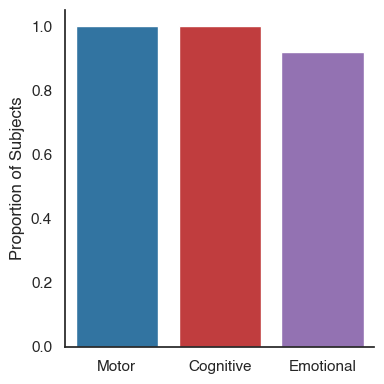

In [7]:

labels=['Motor', 'Cognitive', 'Emotional']
plt.figure(figsize=(4,4))
bar3=sns.barplot(x=labels, hue=labels,y=[1,1,pct_w_something['cnrs']], palette=pal)
bar3.set_ylabel('Proportion of Subjects')

# import matplotlib.patches as patches
# present_patch = patches.Patch(color='#1F77B4', label="Present")
# absent_patch = patches.Patch(color="#ABCBE0", label="Absent")
# pending_patch = patches.Patch(color="#9F9F9F", label="Pending")

# bar3.legend(handles=[pending_patch], labels=['Pending'], loc='lower left',bbox_to_anchor=(1, .76), frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig(f'/Users/rm026/Documents/schmahmann/plots/proportion_w_something_in_ground_truth.svg')

In [8]:
yeses={'bars':[],'ccas':[], 'cnrs':[]}
for i, row in merged.iterrows():
    for set in sets:
        gt_row=row[[q+"_gt" for q in q_sets[set]]]

        counts=gt_row.value_counts()
        if counts.get(2,0)==0:
            proportion_yes=0
        else:
            proportion_yes=counts.get(2,0)/(counts.get(1,0)+counts.get(2,0))
        yeses[set].append(proportion_yes)

merged['bars_proportion_yes']=yeses['bars']
merged['ccas_proportion_yes']=yeses['ccas']
merged['cnrs_proportion_yes']=yeses['cnrs']
merged[['bars_proportion_yes','ccas_proportion_yes','cnrs_proportion_yes']]

,bars_proportion_yes,ccas_proportion_yes,cnrs_proportion_yes
0,1.0,0.00,0.000000
1,1.0,0.00,0.333333
2,1.0,0.00,0.000000
3,1.0,0.00,0.000000
4,1.0,0.00,0.000000
...,...,...,...
80,0.6,0.75,0.000000
81,1.0,0.00,0.800000
82,0.8,0.00,0.000000
83,1.0,1.00,0.625000


/var/folders/18/_vyb12pj2pn9yc0162_pk3cc0000gp/T/ipykernel_53609/630037316.py:11: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  hist2.legend(hist1.get_legend_handles_labels()+hist2.get_legend_handles_labels()+hist3.get_legend_handles_labels(),


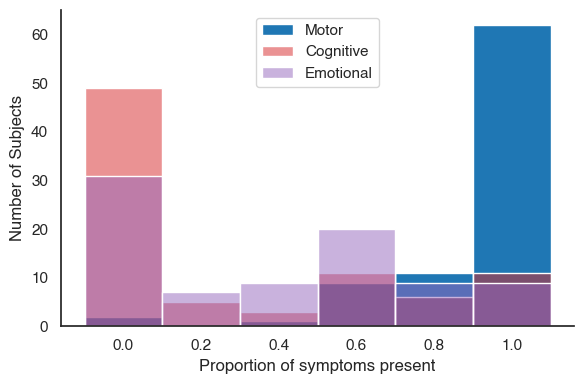

In [9]:
pal={'Motor':'#1F77B4', 'Cognitive':'#D62728', "Emotional":'#9467BD'}
plt.figure(figsize=(6,4))
hist_dat=pd.DataFrame({'set':['Motor']*len(merged)+['Cognitive']*len(merged)+['Emotional']*len(merged),
                       'proportion_yes':list(merged['bars_proportion_yes'])+list(merged['ccas_proportion_yes'])+list(merged['cnrs_proportion_yes'])})
# hist=sns.histplot(data=hist_dat, x='proportion_yes', hue='set', alpha=0.6, palette=['#1F77B4','#D62728'])
hist1=sns.histplot(x=merged['bars_proportion_yes'], hue=['Motor']*len(merged), alpha=1, palette=pal, bins=np.arange(-0.1,1.1,0.2))
hist2=sns.histplot(x=merged['ccas_proportion_yes'], hue=['Cognitive']*len(merged),alpha=0.5, palette=pal, bins=np.arange(-0.1,1.1,0.2))
hist3=sns.histplot(x=merged['cnrs_proportion_yes'], hue=['Emotional']*len(merged), alpha=0.5, palette=pal, bins=np.arange(-0.1,1.1,0.2))
hist2.set_xlabel('Proportion of symptoms present')
hist2.set_ylabel('Number of Subjects')
hist2.legend(hist1.get_legend_handles_labels()+hist2.get_legend_handles_labels()+hist3.get_legend_handles_labels(), 
             labels=['Motor','Cognitive', "Emotional"], loc='upper center')
sns.despine()
plt.tight_layout()
plt.savefig(f'/Users/rm026/Documents/schmahmann/plots/symptom_proportion_histogram_consistent_bins.svg')

In [10]:
n_known={}
for set in sets:
    total=0
    for q in q_sets[set]:
        num_zeros = gt[q].value_counts()[0] if 0 in gt[q].value_counts() else 0
        total+=len(gt)-num_zeros
    if set=='cnrs':
        n_known[set]=total/(35*len(gt))
    else:
        n_known[set]=total/(len(q_sets[set])*len(gt))
n_known

{'bars': 1.0,
 'ccas': np.float64(0.2847058823529412),
 'cnrs': np.float64(0.19058823529411764)}

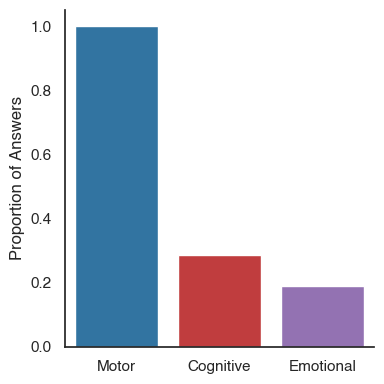

In [11]:
labels=['Motor', 'Cognitive', 'Emotional']
plt.figure(figsize=(4,4))
bar=sns.barplot(x=labels, hue=labels,y=[1,n_known['ccas'],n_known['cnrs']], palette=pal)
bar.set_ylabel('Proportion of Answers')

# import matplotlib.patches as patches
# present_patch = patches.Patch(color='#1F77B4', label="Present")
# absent_patch = patches.Patch(color="#ABCBE0", label="Absent")
# pending_patch = patches.Patch(color="#9F9F9F", label="Pending")

sns.despine()
plt.tight_layout()
plt.savefig(f'/Users/rm026/Documents/schmahmann/plots/known_questions_proportion.svg')

In [12]:
# def accuracy(conf_matrix):
    
#     total_questions=sum([sum(row) for row in conf_matrix])
#     good_answers=0
#     for i in range(len(conf_matrix)):
#         if conf_matrix.shape==(2,3):
#             good_answers += conf_matrix[i][i+1]
#         elif conf_matrix.shape==(2,2) or conf_matrix.shape==(3,3):
#             good_answers += conf_matrix[i][i]
#         else:
#             raise ValueError(f"confusion matrix has shape {conf_matrix.shape}")
#     accuracy=good_answers/total_questions

#     return accuracy

# def sensitivity(conf_matrix, yes_col=2):
#     total=sum(conf_matrix[yes_col])
#     true_positives=conf_matrix[yes_col][yes_col]
#     return true_positives/total

# def specificity(conf_matrix, no_col=1):
#     total=sum(conf_matrix[no_col])
#     true_negatives=conf_matrix[no_col][no_col]
#     return true_negatives/total

# def pos_pred_power(conf_matrix, yes_col=2):
#     true_positives=conf_matrix[yes_col][yes_col]
#     predicted_positives=sum([conf_matrix[i][yes_col] for i in range(len(conf_matrix))])
#     return true_positives/predicted_positives

# def neg_pred_power(conf_matrix, no_col=1):
#     true_negatives=conf_matrix[no_col][no_col]
#     predicted_negatives=sum([conf_matrix[i][no_col] for i in range(len(conf_matrix))])
#     return true_negatives/predicted_negatives

# def combine_no_and_unknown(conf):
#     output=np.array([conf[0]+conf[1], conf[2]])
#     output=np.array([output[:,0]+output[:,1], output[:,2]]) 
#     return output

# def ignore_unknown(conf):
#     return conf[1:,1:]

# def ignore_ground_truth_unknown(conf):
#     return conf[1:]

# def confusion_matrix(truth_vector, pred_vector):
#     matrix=[[0,0,0],
#             [0,0,0],
#             [0,0,0]]
#     for truth, pred in zip(truth_vector,pred_vector):
#         if type(truth)==str and truth.lower()=='o':
#             truth=0
#         if type(pred)==str:
#             print(f"Skipping string prediction: {pred}")
#             continue
        
#         matrix[int(float(truth))][int(float(pred))]+=1

#     return np.array(matrix)

# def statistical_df(confusion_matrix_dict,no_cols=1,yes_cols=2):
    
#     confusion_matrix_dict['overall']=sum(list(confusion_matrix_dict.values()))

#     out_df=pd.DataFrame.from_dict({q:accuracy(matrix) for q, matrix in confusion_matrix_dict.items()}, orient='index', columns=['accuracy'])
    
#     out_df['specificity']=[specificity(matrix,no_cols) for q, matrix in confusion_matrix_dict.items()]
#     out_df['sensitivity']=[sensitivity(matrix, yes_cols) for q, matrix in confusion_matrix_dict.items()]
#     out_df['positive predictive power']=[pos_pred_power(matrix, yes_cols) for q, matrix in confusion_matrix_dict.items()]
#     out_df['negative predictive power']=[neg_pred_power(matrix, no_cols) for q, matrix in confusion_matrix_dict.items()]

#     out_df.reset_index(inplace=True, names='question')
    
#     return out_df

In [13]:
score_names=['accuracy','sensitivity','specificity','positive predictive power', 'negative predictive power']

# def plot_scores(df, yrange=(0.1,1.03),title='Schmahmann CCAS evaluation by question',
#                 filename=f'/Users/rm026/Documents/schmahmann/plots/stats_by_question.png'):
    
#     colors=['Tomato', 'blue', 'green','purple','orange']

#     plt.figure(figsize=(6,4))
#     markers=['o','s','^', 'D']
#     for i, score in enumerate(score_names):
#         question_name=df['question'].str.title()
#         plt.plot(question_name, df[score], marker=markers[i], color=colors[i])

#     plt.title(title)
#     plt.ylim(yrange)
#     plt.xticks(rotation=45, ha='right')
#     plt.legend([score.capitalize() for score in score_names])
#     plt.savefig(filename, bbox_inches='tight')
#     plt.show()

# def data_for_boxplot(confs, scores):

#     confs=confs[confs['question']!='overall']
#     out=[confs[score] for score in scores]
#     return out

# def boxplot(df, scores,
#               labels,
#               title=None,
#               filename='raincloud_plot.png',
#               ylim=(-10,10),):

#     data=data_for_boxplot(df, scores)

#     fig, ax = plt.subplots(figsize=(6,4))
    
#     # Create a list of colors for the boxplots based on the number of features you have
#     boxplots_colors = ['darkred', 'blue', 'green','purple','orange']
    
#     # Boxplot data
#     bp = ax.boxplot(data, 
#                     # notch=True,
#                     patch_artist = True, 
#                     vert = True,
#                     showfliers=False,
#                    medianprops={'linewidth':1.5},
#                 #    whiskerprops={'linewidth':2},
#                    capprops={'linewidth':2}
#                    )
    
#     # Change to the desired color and add transparency
#     for patch, color in zip(bp['boxes'], boxplots_colors):
#         patch.set_facecolor(color)
#         # patch.set_alpha(0.8)
    
#     # Create a list of colors for the scatter plots based on the number of features you have
#     scatter_colors = ['tomato', 'teal', 'lime', 'violet', 'tangerine']
    
#     # Scatterplot data
#     for idx, features in enumerate(data):
#         # Add jitter effect so the features do not overlap on the y-axis
#         y = np.full(len(features), idx + .65)
#         idxs = np.arange(len(y))
#         out = y.astype(float)
#         out.flat[idxs] += np.random.uniform(low=-.05, high=.05, size=len(idxs))
#         y = out
#         plt.scatter(y, features, c=scatter_colors[idx], edgecolors='black', alpha=.8)
    
#     plt.xticks(np.arange(1,len(labels)+1,1), labels)  # Set text labels.
#     # plt.ylabel('Damage Score', size='medium')
#     plt.title(title)
#     plt.ylim(ylim)
#     plt.savefig(filename,bbox_inches='tight')
#     plt.show()



In [68]:
from EvaluationTools import *


In [15]:
bars_conf=np.array([[0,0,0],
                    [0,0,0],
                    [0,0,0]])

for q in q_sets['bars']:
    bars_conf+=confusion_matrix(merged[q+'_gt'],merged[q+'_ai'])

bars_df=pd.DataFrame(bars_conf,columns=['Predict yes','Predict no','Predict unknown'],index=['Truth yes','Truth no','Truth unknown'])
bars_df, ignore_ground_truth_unknown(bars_conf)

(               Predict yes  Predict no  Predict unknown
 Truth yes              380           3                0
 Truth no                 0          42                0
 Truth unknown            0           0                0,
 array([[380,   3,   0],
        [  0,  42,   0]]))

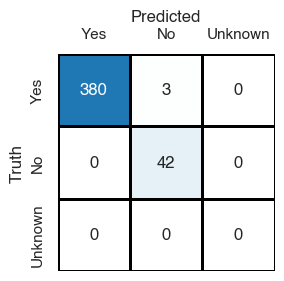

In [16]:

from matplotlib.colors import LinearSegmentedColormap

# def plot_conf_matrix(array, cmap='Blues', filename=None):

#     plt.figure(figsize=(4,4))
#     df_cm = pd.DataFrame(array, range(len(array)), range(len(array)))
#     # plt.figure(figsize=(10,7))
#     # sns.set(font_scale=1.4) # for label size
#     map=sns.heatmap(df_cm, annot=True,
#                 fmt=".0f",
#                 #  annot_kws={"size": 16},
#                 cbar=False, cmap=cmap,
#                 linewidths=1, square=True, linecolor='black') 
#     map.set_xlabel('Predicted',)
#     map.set_xticklabels(['Unknown','No','Yes'])
#     map.set_yticklabels(['Unknown','No','Yes'])
#     map.xaxis.set_label_position('top')
#     map.xaxis.tick_top()

#     map.tick_params(left=False, top=False)
#     map.set_ylabel('Truth')

#     plt.tight_layout()
#     if filename:
#         plt.savefig(filename, bbox_inches='tight')
#     plt.show()


bars_cmap = LinearSegmentedColormap.from_list(
    "white_to_blue",
    ["#ffffff", '#1F77B4']
)

plot_conf_matrix(bars_conf, cmap=bars_cmap, filename='/Users/rm026/Documents/schmahmann/plots/bars_confusion_matrix.svg')

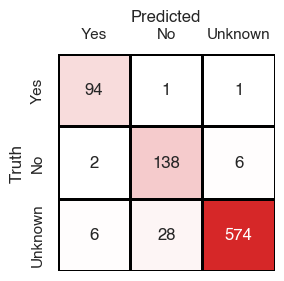

In [17]:
ccas_conf=np.array([[0,0,0],
                    [0,0,0],
                    [0,0,0]])

for q in q_sets['ccas']:
    ccas_conf+=confusion_matrix(merged[q+'_gt'],merged[q+'_ai'])

ccas_cmap = LinearSegmentedColormap.from_list(
    "white_to_red",
    ["#ffffff", "#D62728"]
)

ccas_df=pd.DataFrame(ccas_conf,columns=['Predict yes','Predict no','Predict unknown'],index=['Truth yes','Truth no','Truth unknown'])
plot_conf_matrix(ccas_conf, cmap=ccas_cmap, filename='/Users/rm026/Documents/schmahmann/plots/ccas_confusion_matrix.svg')

In [18]:
ccas_human_approved_accuracy=1-(7/302) # this is number of errors I didn't catch in the explanations (so just the false unknowns), as proportion of everything which is not unknown in ground truth
ccas_human_approved_accuracy

0.9768211920529801

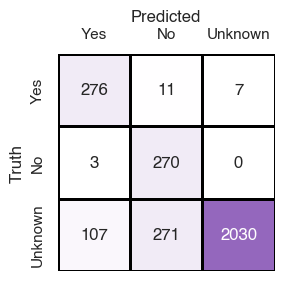

In [19]:
cnrs_conf=np.array([[0,0,0],
                    [0,0,0],
                    [0,0,0]])

for q in q_sets['cnrs']:
    cnrs_conf+=confusion_matrix(merged[q+'_gt'],merged[q+'_ai'])
    

cnrs_cmap = LinearSegmentedColormap.from_list(
    "white_to_purple",
    ["#ffffff", pal['Emotional']]
)

cnrs_df=pd.DataFrame(cnrs_conf,columns=['Predict yes','Predict no','Predict unknown'],index=['Truth yes','Truth no','Truth unknown'])
plot_conf_matrix(cnrs_conf, cmap=cnrs_cmap, filename='/Users/rm026/Documents/schmahmann/plots/cnrs_confusion_matrix.svg')

In [20]:
print(cnrs_conf)
print(ignore_ground_truth_unknown(cnrs_conf))
print(accuracy(ignore_ground_truth_unknown(cnrs_conf)))

[[ 276   11    7]
 [   3  270    0]
 [ 107  271 2030]]
[[276  11   7]
 [  3 270   0]]
0.9629629629629629


In [21]:
cnrs_human_approved_accuracy=1-(7/567) # this is number of errors I didn't catch in the explanations (so just the false unknowns), as proportion of everything which is not unknown in ground truth
cnrs_human_approved_accuracy

0.9876543209876543

In [22]:
confusions={}
stats={}
ignoring_unk={}

for set in sets:
    confusions[set]={}
    ignoring_unk[set]={}
    for q in q_sets[set]:
        conf_matrix=confusion_matrix(merged[q+'_gt'], merged[q+'_ai'])
        confusions[set][q]=conf_matrix
        ignoring_unk[set][q]=ignore_ground_truth_unknown(conf_matrix)

    stats[set]=statistical_df(ignoring_unk[set],)


/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:28: RuntimeWarning: invalid value encountered in scalar divide
  accuracy=good_answers/total_questions
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:39: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/ground_truth_neg
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:34: RuntimeWarning: invalid value encountered in scalar divide
  return true_positives/ground_truth_pos
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:44: RuntimeWarning: invalid value encountered in scalar divide
  return true_positives/predicted_positives
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:49: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/predicted_negatives


In [23]:
stats['cnrs']

,question,accuracy,specificity,sensitivity,positive predictive power,negative predictive power
0,attention a1,0.976744,1.000000,0.965517,1.000000,0.933333
1,attention a2,0.750000,1.000000,0.727273,1.000000,1.000000
2,attention a3,0.800000,1.000000,0.750000,1.000000,0.500000
3,attention a4,1.000000,NaN,1.000000,1.000000,NaN
4,attention a5,NaN,NaN,NaN,NaN,NaN
5,attention b6,1.000000,1.000000,1.000000,1.000000,1.000000
6,attention b7,0.750000,NaN,0.750000,1.000000,NaN
7,attention b8,1.000000,1.000000,1.000000,1.000000,1.000000
8,attention b9,0.857143,NaN,0.857143,1.000000,0.000000
9,emotion a10,1.000000,1.000000,1.000000,1.000000,1.000000


/var/folders/18/_vyb12pj2pn9yc0162_pk3cc0000gp/T/ipykernel_53609/1754394996.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar1=sns.barplot(data=accdf,x='set',y='accuracy',  palette=pal.values(),)
/var/folders/18/_vyb12pj2pn9yc0162_pk3cc0000gp/T/ipykernel_53609/1754394996.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar1.set_xticklabels(labels)


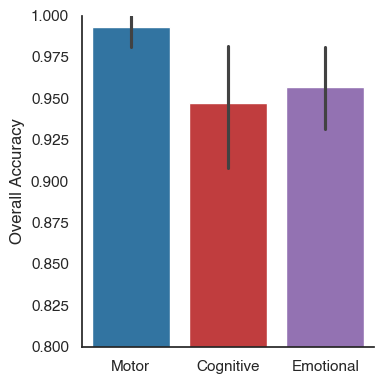

In [24]:
setstuff=[]
ques=[]
acc=[]
for thing in sets:
    setstuff+=[thing]*len(stats[thing])
    acc+=stats[thing]['accuracy'].values.tolist()
# setstuff.append('cnrs')
# acc.append(1)
accdf=pd.DataFrame()
accdf['set']=setstuff
accdf['accuracy']=acc

labels=['Motor', 'Cognitive', 'Emotional']
plt.figure(figsize=(4,4))
bar1=sns.barplot(data=accdf,x='set',y='accuracy',  palette=pal.values(),)
# bar2=sns.barplot(x=labels, hue=labels,y=[0,1,0], palette=['#FFFFFF','#FFFFFF', '#FFFFFF',])
# bar3=sns.barplot(x=labels, hue=labels,y=[accuracy(bars_conf),accuracy(ccas_conf),0], palette=['#FFFFFF',])
bar1.set_ylabel('Overall Accuracy')

plt.ylim(.8,1)
import matplotlib.patches as patches
# present_patch = patches.Patch(color='#1F77B4', label="Present")
# absent_patch = patches.Patch(color="#ABCBE0", label="Absent")
# pending_patch = patches.Patch(color="#9F9F9F", label="Pending")
bar1.set_xticklabels(labels)
bar1.set_xlabel('')
# bar1.legend(handles=[pending_patch], labels=['Pending'], loc='lower left',bbox_to_anchor=(1, .76), frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(f'/Users/rm026/Documents/schmahmann/plots/total_accuracy.svg')

In [26]:

dfs={}
for set in sets:

    q=[]
    stat_names=[]
    values=[]
    for i,row in stats[set].iterrows():
        for stat in score_names:
            q.append(row['question'])
            stat_names.append(stat.title())
            values.append(row[stat])
    dfs[set]=pd.DataFrame({'question':q, 'statistic':stat_names, 'value':values})
dfs['ccas']

,question,statistic,value
0,semantic fluency,Accuracy,0.857143
1,semantic fluency,Sensitivity,1.000000
2,semantic fluency,Specificity,0.733333
3,semantic fluency,Positive Predictive Power,1.000000
4,semantic fluency,Negative Predictive Power,1.000000
5,phonemic fluency,Accuracy,0.956522
6,phonemic fluency,Sensitivity,0.916667
7,phonemic fluency,Specificity,1.000000
8,phonemic fluency,Positive Predictive Power,1.000000
9,phonemic fluency,Negative Predictive Power,0.916667


In [ ]:
schdata=pd.read_csv('/Users/rm026/Documents/schmahmann/BARS-CCAS-CNRS_nearest_higher-is-better.csv')
schdata[['TotalBarsScore', "TotalCCASRawScore", "CNRSTotScore"]]
schdata['bars']=-schdata['TotalBarsScore']/30
schdata['ccas']=1-schdata['TotalCCASRawScore']/120
schdata['cnrs']=-schdata['CNRSTotScore']/105


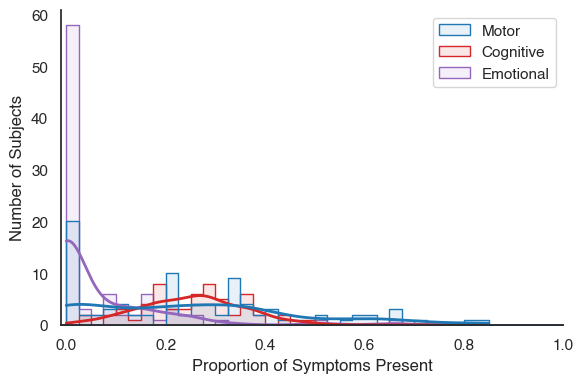

In [ ]:
pal={'Motor':'#1F77B4', 'Cognitive':'#D62728', 'Emotional':'#9467BD'}
plt.figure(figsize=(6,4))
hist_dat=pd.DataFrame({'set':['Motor']*len(schdata)+['Cognitive']*len(schdata)+['Emotional']*len(schdata),
                       'score':list(schdata['bars'])+list(schdata['ccas'])+list(schdata['cnrs'])})
hist=sns.histplot(data=hist_dat, x='score', hue='set',  stat="count",
                  bins=np.arange(-0.05,1.05,0.025),
                  alpha=0.1, 
                  palette=pal,element="step",
                  kde=True, 
                  kde_kws={'bw_adjust':0.8},
                  line_kws={'linewidth':2.,}
                )
sns.despine()
hist.get_legend().set_title('')
hist.set_xlim(-0.01,1)
hist.set_xlabel('Proportion of Symptoms Present')
hist.set_ylabel('Number of Subjects')
hist.grid(False)
plt.tight_layout()
# plt.savefig(f'/Users/rm026/Documents/schmahmann/plots/symptom_proportion_schmahmann_histogram.svg')


In [33]:
ccas_conf

array([[ 94,   1,   1],
       [  2, 138,   6],
       [  6,  28, 574]])

In [73]:
import ptitprince as pt

def other_rc(stats_df, color, filename, ylims=None, debug=False):

    setstuff=[]
    cols=[]
    acc=[]
    for col in stats_df.columns[2:]:
        setstuff+=['ccas']*len(stats_df)
        cols+=[col]*len(stats_df)
        acc+=stats_df[col].values.tolist()
    accdf=pd.DataFrame()
    accdf['set']=setstuff
    accdf['scores']=acc
    accdf['scoretype']=cols
    if debug: 
        print(accdf[accdf['scoretype']=='specificity'])


    plt.figure(figsize=(4,4))
    rc=pt.RainCloud(data=accdf, y='scores',x='scoretype',hue='scoretype',
                bw=0.5, cut=0, orient='v', palette=[color]*4, width_viol=.5, width_box=.3,)
    rc.set_xticklabels(["Sensitivity","Specificity","NPV",'PPV'])

    rc.set_xlabel('')
    # auto_y_min, auto_y_max=rc.get_ylim()
    # rc.set_ylim((auto_y_min, 1))
    rc.set_ylim(ylims)
    rc.set_ylabel('Score')
    rc.grid(False)
    sns.despine()
    plt.tight_layout()
    plt.savefig(filename)


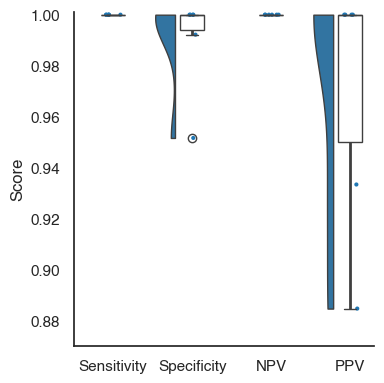

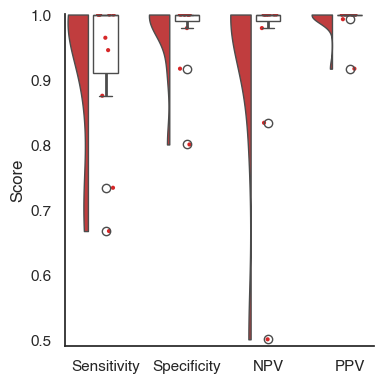

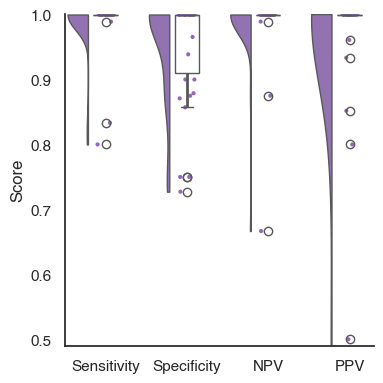

In [52]:
other_rc(stats['bars'], pal['Motor'], filename='/Users/rm026/Documents/schmahmann/plots/bars_raincloud_plot.svg', ylims=(.87,1.001))
other_rc(stats['ccas'], pal['Cognitive'], filename='/Users/rm026/Documents/schmahmann/plots/ccas_raincloud_plot.svg', ylims=(.49,1.001))
other_rc(stats['cnrs'], pal['Emotional'], filename='/Users/rm026/Documents/schmahmann/plots/cnrs_raincloud_plot.svg', ylims=(.49,1.001))


In [37]:
stats_table_data=[]

for set in sets:
    table_row=[set]
    for col in stats[set].columns:
        if col!='question':
            mean_stat=stats[set][col].mean()
            # print(set, col, mean_stat)
            table_row.append(mean_stat)
    stats_table_data.append(table_row)

stats_table=pd.DataFrame(stats_table_data, columns=['dataset']+list(stats['bars'].columns)[1:])
stats_table.round(3)

,dataset,accuracy,specificity,sensitivity,positive predictive power,negative predictive power
0,bars,0.993,1.000,0.991,1.000,0.970
1,ccas,0.947,0.926,0.972,0.938,0.992
2,cnrs,0.957,0.987,0.953,0.986,0.935


In [38]:
ccas_conf

array([[ 94,   1,   1],
       [  2, 138,   6],
       [  6,  28, 574]])

In [39]:
def human_checked(confusion):
    new=[[confusion[0,0]+confusion[0,1],0,confusion[0,2]],
         [0,confusion[1][0]+confusion[1][1],confusion[1,2]],
         [0,0,confusion[2].sum()]]

    return np.asarray(new)

human={}
for set, conf in zip(sets,[bars_conf,ccas_conf,cnrs_conf]):
    human[set]=human_checked(conf)
    print(set, accuracy(ignore_ground_truth_unknown(human[set])))


bars 1.0
ccas 0.9710743801652892
cnrs 0.9876543209876543


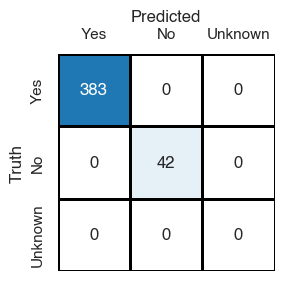

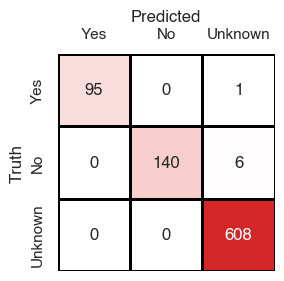

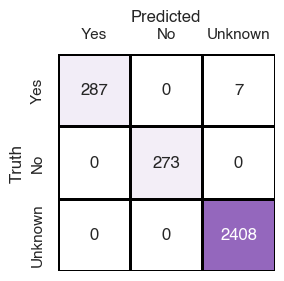

In [40]:
cmaps={'bars':bars_cmap,
       'ccas':ccas_cmap,
       'cnrs':cnrs_cmap}

for set, conf in human.items():
    plot_conf_matrix(conf, cmap=cmaps[set], filename=f'/Users/rm026/Documents/schmahmann/plots/{set}_confusion_matrix_human_eval.svg')

In [71]:
post_confs={set:{q:ignore_ground_truth_unknown(human_checked(conf)) for q, conf in q_dict.items()} for set, q_dict in confusions.items()}
post_stats={set:statistical_df(q_dict) for set, q_dict in post_confs.items()}
post_stats['bars']

/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:28: RuntimeWarning: invalid value encountered in scalar divide
  accuracy=good_answers/total_questions
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:39: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/ground_truth_neg
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:34: RuntimeWarning: invalid value encountered in scalar divide
  return true_positives/ground_truth_pos
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:44: RuntimeWarning: invalid value encountered in scalar divide
  return true_positives/predicted_positives
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:49: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/predicted_negatives


,question,accuracy,specificity,sensitivity,positive predictive power,negative predictive power
0,gait,1.0,1.0,1.0,1.0,1.0
1,heel–shin,1.0,1.0,1.0,1.0,1.0
2,speech,1.0,1.0,1.0,1.0,1.0
3,oculomotor,1.0,1.0,1.0,1.0,1.0
4,finger-nose,1.0,1.0,1.0,1.0,1.0
5,overall,1.0,1.0,1.0,1.0,1.0


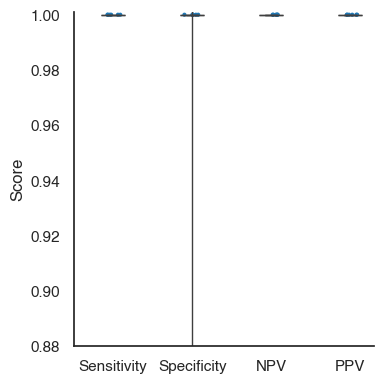

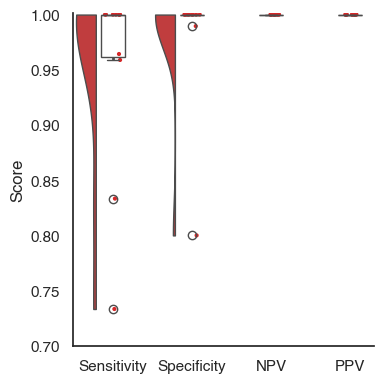

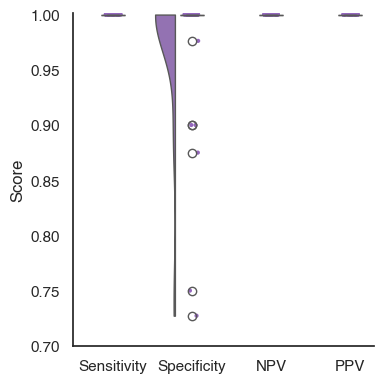

In [75]:
other_rc(post_stats['bars'], pal['Motor'], filename='/Users/rm026/Documents/schmahmann/plots/post-eval_bars_raincloud_plot.svg', ylims=(.88,1.001))
other_rc(post_stats['ccas'], pal['Cognitive'], filename='/Users/rm026/Documents/schmahmann/plots/post-eval_ccas_raincloud_plot.svg', ylims=(.7,1.001))
other_rc(post_stats['cnrs'], pal['Emotional'], filename='/Users/rm026/Documents/schmahmann/plots/post-eval_cnrs_raincloud_plot.svg', ylims=(.7,1.001))
